# Universidad del Valle de Guatemala
## Departamento de Ciencias de la Computación
## Inteligencia Artificial - sección 10

# Proyecto No. 2

### Nadissa Vela - 23764
### Cristian Túnchez - 231359

--------



# Task 1 — Configuración Segura de la Red
## CSP y Factor Graphs aplicados a Ciberseguridad
  
Asignación de protocolos de seguridad a servidores en una red distribuida,  
garantizando que ningún par de servidores conectados comparta el mismo protocolo (movimiento lateral).



### Modelado Formal como CSP con Factor Graphs

Dado un grafo $G = (V, E)$ que representa la red de servidores:

| Componente CSP | Definición en el Problema |
|---|---|
| **Variables** | $X = \{X_1, X_2, \ldots, X_n\}$ — un servidor por variable |
| **Dominios** | $\text{Dom}_i = \{\text{Rojo}, \text{Verde}, \text{Azul}, \text{Amarillo}\}$ para todo $i$ |
| **Factores** | $f_{ij}(X_i, X_j) = [X_i \neq X_j]$ para cada arista $(i,j) \in E$ |

### Factor Graph

$$\text{Weight}(x) = \prod_{(i,j) \in E} f_{ij}(x_i, x_j)$$

- Cada factor $f_{ij}$ es una **restricción binaria** que devuelve 1 si $x_i \neq x_j$, y 0 si son iguales.
- Una asignación es **consistente** iff $\text{Weight}(x) = 1$ (todas las restricciones satisfechas).
- **Objetivo:** $\arg\max_x \text{Weight}(x)$ — encontrar cualquier asignación con peso máximo 1.

### Restricción de Seguridad

$$\forall (i, j) \in E: \quad \text{protocolo}(i) \neq \text{protocolo}(j)$$

Esto evita vulnerabilidades de **movimiento lateral**: si un servidor es comprometido, el protocolo diferente en servidores vecinos limita la propagación del ataque.


### Imports y Generación del Grafo

In [95]:
import random
import time
import copy
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Protocolos de seguridad (representados como colores)
PROTOCOLS = ["Rojo", "Verde", "Azul", "Amarillo"]
PROTOCOL_COLORS = {
    "Rojo":     "#e74c3c",
    "Verde":    "#2ecc71",
    "Azul":     "#3498db",
    "Amarillo": "#f1c40f",
    None:       "#bdc3c7"   # sin asignar
}

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [96]:
def generate_network(n_nodes: int = 17, edge_prob: float = 0.35, seed: int = SEED) -> nx.Graph:
    """
    Genera un grafo aleatorio conectado que representa la red de servidores.
    Usa el modelo Erdős–Rényi y garantiza conectividad.
    """
    rng = random.Random(seed)
    
    while True:
        G = nx.erdos_renyi_graph(n_nodes, edge_prob, seed=seed)
        if nx.is_connected(G):
            # Renombrar nodos como "S0", "S1", ...
            mapping = {i: f"S{i}" for i in range(n_nodes)}
            G = nx.relabel_nodes(G, mapping)
            return G
        seed += 1  # probar otra semilla si no está conectado


# Generar red con 17 servidores
G = generate_network(n_nodes=17, edge_prob=0.35)

print(f"Red generada:")
print(f"  Servidores (nodos): {G.number_of_nodes()}")
print(f"  Conexiones (aristas): {G.number_of_edges()}")
print(f"  Grado promedio: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
print(f"  Es conectado: {nx.is_connected(G)}")
print(f"\nServidores: {list(G.nodes())}")

Red generada:
  Servidores (nodos): 17
  Conexiones (aristas): 53
  Grado promedio: 6.24
  Es conectado: True

Servidores: ['S0', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16']


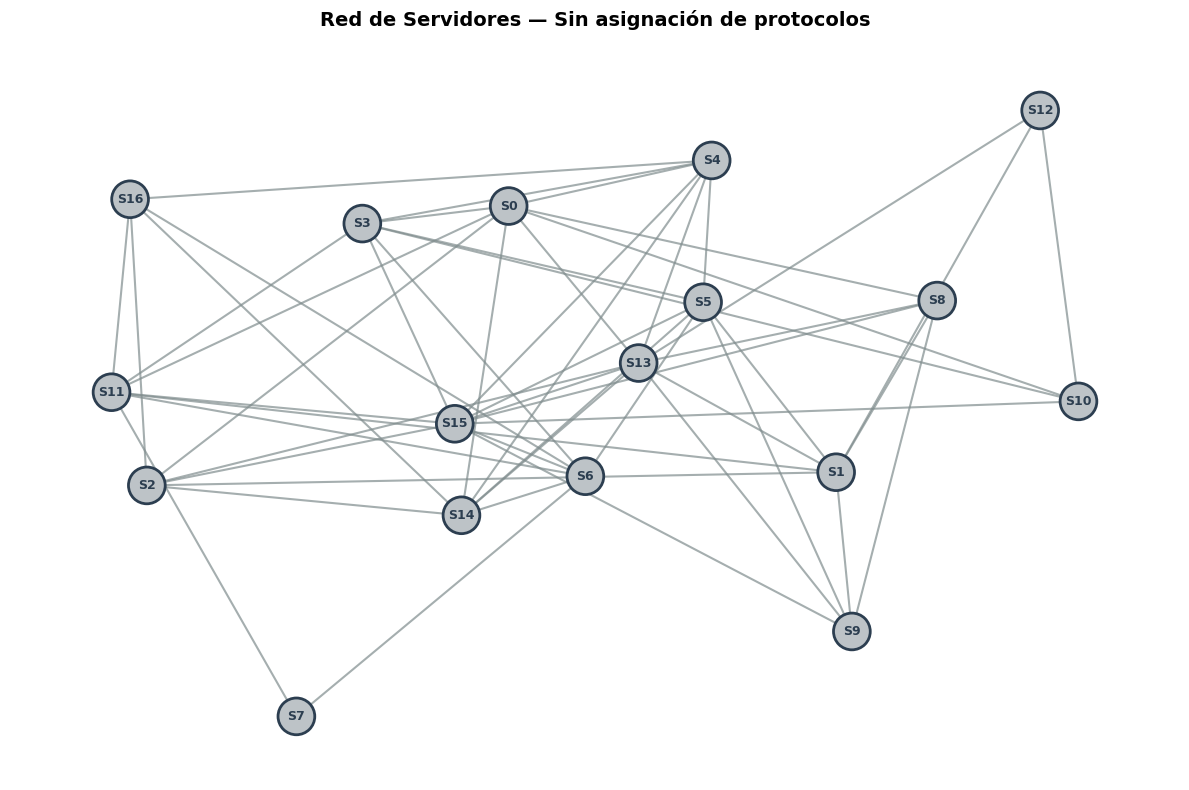

In [97]:
def plot_network(G: nx.Graph, assignment: dict = None, title: str = "Red de Servidores"):
    """
    Visualiza la red de servidores. Si hay asignación, colorea los nodos
    con el protocolo asignado.
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=SEED, k=1.5)
    
    node_colors = []
    for node in G.nodes():
        protocol = assignment.get(node) if assignment else None
        node_colors.append(PROTOCOL_COLORS[protocol])
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700,
                           edgecolors="#2c3e50", linewidths=2, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="#7f8c8d", width=1.5,
                           alpha=0.7, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold",
                            font_color="#2c3e50", ax=ax)
    
    # Leyenda de protocolos
    if assignment:
        patches = [mpatches.Patch(color=PROTOCOL_COLORS[p], label=f"Protocolo {p}")
                   for p in PROTOCOLS]
        patches.append(mpatches.Patch(color=PROTOCOL_COLORS[None], label="Sin asignar"))
        ax.legend(handles=patches, loc="upper left", fontsize=10)
    
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_network(G, title="Red de Servidores — Sin asignación de protocolos")

### Implementación del CSP

In [98]:
class NetworkSecurityCSP:
    """
    Modela el problema de asignación de protocolos de seguridad
    como un Problema de Satisfacción de Restricciones (CSP).

    Factor Graph:
      - Variables: servidores de la red
      - Dominio_i: {Rojo, Verde, Azul, Amarillo}
      - Factor f_ij(Xi, Xj) = [Xi != Xj] para cada arista (i,j)
    """

    def __init__(self, graph: nx.Graph, protocols: list):
        self.graph     = graph
        self.variables = list(graph.nodes())
        self.protocols = protocols
        # Dominio inicial: todos los protocolos disponibles para cada servidor
        self.domains   = {v: list(protocols) for v in self.variables}
        # Vecinos: servidores conectados directamente
        self.neighbors = {v: list(graph.neighbors(v)) for v in self.variables}

    # ------------------------------------------------------------------
    # Factor Graph
    # ------------------------------------------------------------------

    def factor(self, xi: str, xj: str, val_i, val_j) -> int:
        """
        f_ij(xi, xj) = 1 si val_i != val_j (restricción satisfecha), 0 si son iguales.
        Solo se evalúa si existe arista entre xi y xj.
        """
        if self.graph.has_edge(xi, xj):
            return int(val_i != val_j)
        return 1  # sin arista → no hay restricción → factor neutro

    def weight(self, assignment: dict) -> int:
        """
        Weight(x) = producto de todos los factores sobre aristas asignadas.
        Una asignación completa es consistente iff Weight(x) = 1.
        """
        w = 1
        checked = set()
        for node, val in assignment.items():
            for neighbor in self.neighbors[node]:
                if neighbor in assignment:
                    edge = tuple(sorted((node, neighbor)))
                    if edge not in checked:
                        w *= self.factor(node, neighbor, val, assignment[neighbor])
                        checked.add(edge)
                        if w == 0:
                            return 0
        return w

    def delta(self, assignment: dict, xi: str, val) -> int:
        """
        δ = producto de los factores dependientes de Xi dado la asignación parcial actual.
        Evalúa solo los factores donde xi y su vecino ya están asignados.
        """
        d = 1
        for neighbor in self.neighbors[xi]:
            if neighbor in assignment:
                d *= self.factor(xi, neighbor, val, assignment[neighbor])
                if d == 0:
                    return 0
        return d

    def is_consistent(self, assignment: dict) -> bool:
        """Verifica si la asignación (parcial o completa) es consistente."""
        return self.weight(assignment) == 1

    def __repr__(self):
        return (f"NetworkSecurityCSP("
                f"variables={len(self.variables)}, "
                f"protocols={self.protocols}, "
                f"constraints={self.graph.number_of_edges()})")


csp = NetworkSecurityCSP(G, PROTOCOLS)
print(csp)
print(f"\nEjemplo de vecinos de S0: {csp.neighbors['S0']}")
print(f"Dominio de S0: {csp.domains['S0']}")

NetworkSecurityCSP(variables=17, protocols=['Rojo', 'Verde', 'Azul', 'Amarillo'], constraints=53)

Ejemplo de vecinos de S0: ['S2', 'S3', 'S4', 'S8', 'S10', 'S11', 'S13', 'S14']
Dominio de S0: ['Rojo', 'Verde', 'Azul', 'Amarillo']


### Backtracking Puro (sin heurísticas)

In [99]:
class BacktrackingPure:
    """
    Backtracking Search básico.
    - Selección de variable: orden fijo (lista de variables tal como están).
    - Orden de valores: orden fijo del dominio.
    - Sin lookahead ni propagación de restricciones.
    """

    def __init__(self, csp: NetworkSecurityCSP):
        self.csp             = csp
        self.calls           = 0   # nodos explorados en el árbol
        self.assignments_tried = 0 # asignaciones individuales intentadas

    def solve(self) -> dict | None:
        self.calls = 0
        self.assignments_tried = 0
        assignment = {}
        result = self._backtrack(assignment)
        return result

    def _backtrack(self, assignment: dict) -> dict | None:
        self.calls += 1

        # Caso base: asignación completa
        if len(assignment) == len(self.csp.variables):
            return assignment

        # Seleccionar siguiente variable (orden fijo)
        xi = self._select_variable(assignment)

        # Probar cada valor del dominio (orden fijo)
        for value in self.csp.protocols:
            self.assignments_tried += 1

            # δ: verificar consistencia con vecinos ya asignados
            delta = self.csp.delta(assignment, xi, value)
            if delta == 0:
                continue  # restricción violada → podar

            assignment[xi] = value
            result = self._backtrack(assignment)
            if result is not None:
                return result
            del assignment[xi]

        return None  # backtrack

    def _select_variable(self, assignment: dict) -> str:
        """Orden fijo: primera variable no asignada en la lista original."""
        for var in self.csp.variables:
            if var not in assignment:
                return var


print("BacktrackingPure definido.")

BacktrackingPure definido.


### Backtracking Optimizado (MCV + Lookahead)

In [100]:
class BacktrackingOptimized:
    """
    Backtracking con MCV, Lookahead y LCV.
    """

    def __init__(self, csp: NetworkSecurityCSP):
        self.csp               = csp
        self.calls             = 0
        self.assignments_tried = 0

    def solve(self) -> dict | None:
        self.calls = 0
        self.assignments_tried = 0
        # copia de dominios para no modificar el CSP original
        domains = {v: list(vals) for v, vals in self.csp.domains.items()}
        assignment = {}
        result = self._backtrack(assignment, domains)
        return result

    def _backtrack(self, assignment: dict, domains: dict) -> dict | None:
        self.calls += 1

        # caso base: asignación completa
        if len(assignment) == len(self.csp.variables):
            return assignment

        # MCV: elegir variable con menor dominio restante
        xi = self._select_variable_mcv(assignment, domains)

        # LCV: ordenar valores de menos a más restrictivos
        ordered_values = self._order_values_lcv(xi, assignment, domains)

        for value in ordered_values:
            self.assignments_tried += 1

            # verificar consistencia con vecinos ya asignados
            delta = self.csp.delta(assignment, xi, value)
            if delta == 0:
                continue

            assignment[xi] = value

            # Lookahead: eliminar valores inconsistentes en vecinos
            domains_pruned, failed = self._forward_check(xi, value, assignment, domains)

            if not failed:
                result = self._backtrack(assignment, domains_pruned)
                if result is not None:
                    return result

            del assignment[xi]

        return None  # backtrack

    def _select_variable_mcv(self, assignment: dict, domains: dict) -> str:
        """Variable no asignada con menor cantidad de valores restantes."""
        unassigned = [v for v in self.csp.variables if v not in assignment]
        return min(
            unassigned,
            key=lambda v: (
                len(domains[v]),
                -sum(1 for n in self.csp.neighbors[v] if n not in assignment)
            )
        )

    def _order_values_lcv(self, xi: str, assignment: dict, domains: dict) -> list:
        """Ordena valores del dominio dejando más opciones a los vecinos."""
        def count_conflicts(val):
            conflicts = 0
            for neighbor in self.csp.neighbors[xi]:
                if neighbor not in assignment:
                    if val in domains[neighbor]:
                        conflicts += 1
            return conflicts

        return sorted(domains[xi], key=count_conflicts)

    def _forward_check(self, xi: str, value, assignment: dict,
                        domains: dict) -> tuple[dict, bool]:
        """Elimina value del dominio de cada vecino no asignado. Retorna failed=True si algún dominio queda vacío."""
        new_domains = {v: list(vals) for v, vals in domains.items()}

        for neighbor in self.csp.neighbors[xi]:
            if neighbor not in assignment:
                if value in new_domains[neighbor]:
                    new_domains[neighbor].remove(value)
                if len(new_domains[neighbor]) == 0:
                    return new_domains, True  # dominio vacío, fallo temprano

        return new_domains, False


print("BacktrackingOptimized definido.")


BacktrackingOptimized definido.


### Ejecución y Comparación

In [101]:
def run_solver(solver, name: str) -> dict:
    """Ejecuta el solver y mide métricas de rendimiento."""
    print(f"  Ejecutando: {name}")

    start = time.perf_counter()
    solution = solver.solve()
    elapsed = time.perf_counter() - start

    if solution:
        print(f"\nSolución encontrada")
        print(f"Tiempo          : {elapsed*1000:.4f} ms")
        print(f"Nodos explorados : {solver.calls}")
        print(f"Asignaciones int.: {solver.assignments_tried}")
        print(f"\n  Asignación de protocolos:")
        for server, protocol in sorted(solution.items(), key=lambda x: int(x[0][1:])):
            print(f"    {server:5s} → {protocol}")
    else:
        print("Sin solución")

    return {
        "name":       name,
        "solution":   solution,
        "time_ms":    elapsed * 1000,
        "nodes":      solver.calls,
        "assignments": solver.assignments_tried,
    }


# Instanciar solvers
solver_pure = BacktrackingPure(csp)
solver_opt  = BacktrackingOptimized(csp)

# Ejecutar ambos
results_pure = run_solver(solver_pure, "Backtracking Puro")
print()
results_opt  = run_solver(solver_opt,  "Backtracking Optimizado (MCV + Lookahead + LCV)")

  Ejecutando: Backtracking Puro

Solución encontrada
Tiempo          : 8.0813 ms
Nodos explorados : 780
Asignaciones int.: 3087

  Asignación de protocolos:
    S0    → Rojo
    S1    → Rojo
    S2    → Verde
    S3    → Azul
    S4    → Verde
    S5    → Amarillo
    S6    → Verde
    S7    → Rojo
    S8    → Verde
    S9    → Azul
    S10   → Verde
    S11   → Amarillo
    S12   → Azul
    S13   → Amarillo
    S14   → Azul
    S15   → Rojo
    S16   → Rojo

  Ejecutando: Backtracking Optimizado (MCV + Lookahead + LCV)

Solución encontrada
Tiempo          : 0.8716 ms
Nodos explorados : 18
Asignaciones int.: 17

  Asignación de protocolos:
    S0    → Rojo
    S1    → Rojo
    S2    → Azul
    S3    → Amarillo
    S4    → Azul
    S5    → Verde
    S6    → Azul
    S7    → Rojo
    S8    → Azul
    S9    → Amarillo
    S10   → Verde
    S11   → Verde
    S12   → Azul
    S13   → Verde
    S14   → Amarillo
    S15   → Rojo
    S16   → Rojo


### Verificación de la Solución

In [102]:
def verify_solution(G: nx.Graph, assignment: dict) -> bool:
    """
    Verifica que ningún par de servidores conectados comparta protocolo.
    Evalúa Weight(x) = producto de todos los factores binarios.
    """
    print("Verificando restricciones de la solución:")
    violations = []
    for u, v in G.edges():
        if assignment.get(u) == assignment.get(v):
            violations.append((u, v, assignment.get(u)))

    if violations:
        print(f"{len(violations)} violación(es) encontrada(s):")
        for u, v, p in violations:
            print(f"     {u} ↔ {v}: ambos con '{p}'")
        return False
    else:
        print(f"Todas las {G.number_of_edges()} restricciones satisfechas.")
        print(f"Weight(x) = 1  →  Asignación consistente")
        return True


solution = results_opt["solution"]
verify_solution(G, solution)

Verificando restricciones de la solución:
Todas las 53 restricciones satisfechas.
Weight(x) = 1  →  Asignación consistente


True

### Visualización de la Solución

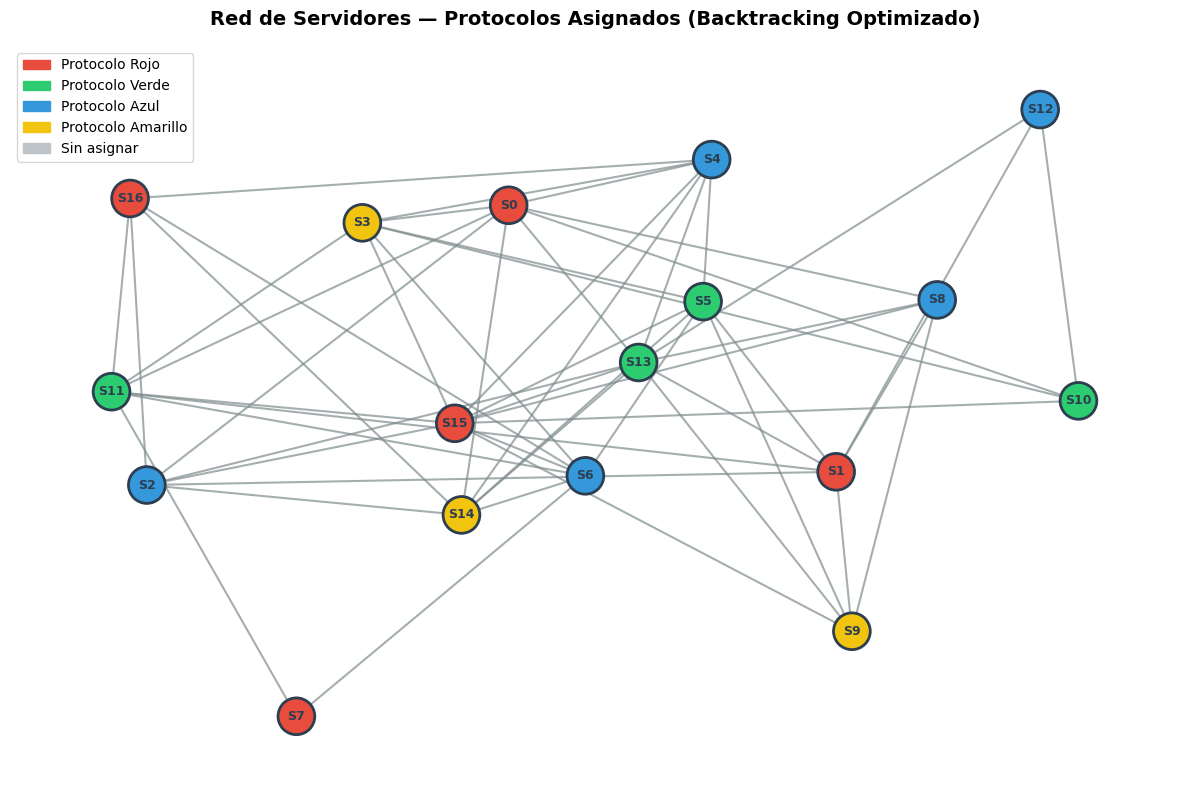

In [103]:
plot_network(
    G,
    assignment=results_opt["solution"],
    title="Red de Servidores — Protocolos Asignados (Backtracking Optimizado)"
)

### Análisis de Rendimiento

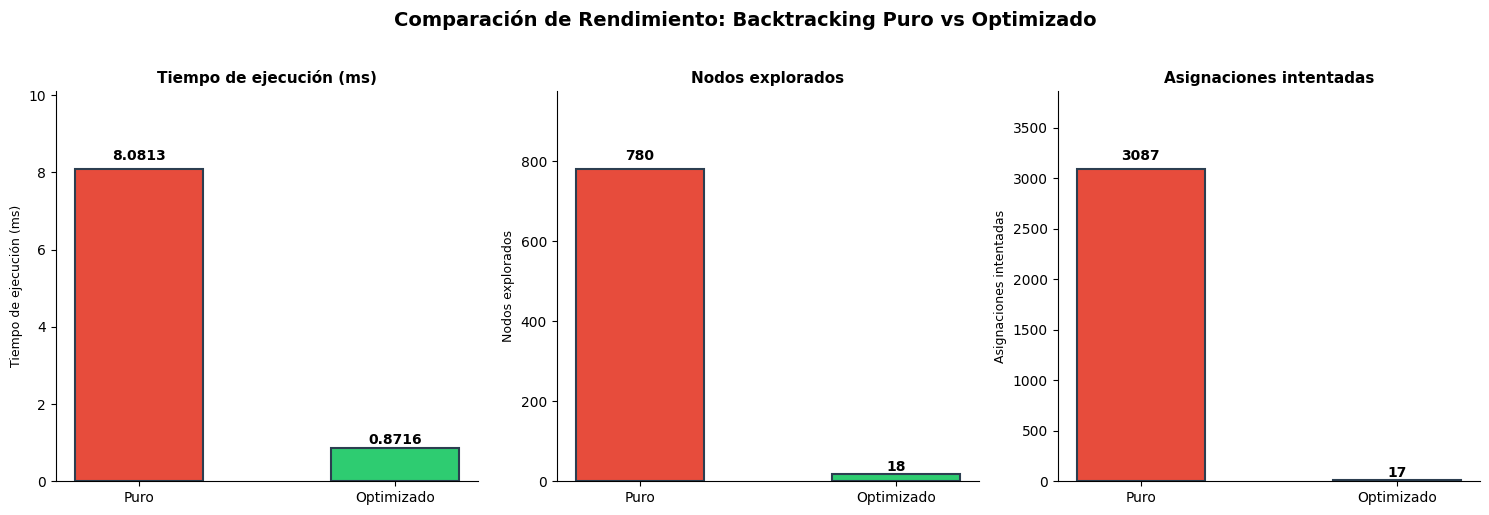


Tabla de Reducción (Puro → Optimizado):
Métrica                              Puro   Optimizado    Reducción
------------------------------------------------------------------
Tiempo de ejecución (ms)           8.0813       0.8716        89.2%
Nodos explorados                      780           18        97.7%
Asignaciones intentadas              3087           17        99.4%


In [104]:
def plot_performance_comparison(results_pure: dict, results_opt: dict):
    """
    Genera gráficas comparativas de las tres métricas clave entre
    Backtracking Puro y Optimizado.
    """
    labels   = ["Puro", "Optimizado"]
    colors   = ["#e74c3c", "#2ecc71"]
    metrics  = [
        ("Tiempo de ejecución (ms)",   [results_pure["time_ms"],    results_opt["time_ms"]]),
        ("Nodos explorados",            [results_pure["nodes"],      results_opt["nodes"]]),
        ("Asignaciones intentadas",     [results_pure["assignments"], results_opt["assignments"]]),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Comparación de Rendimiento: Backtracking Puro vs Optimizado",
                 fontsize=14, fontweight="bold", y=1.02)

    for ax, (title, values) in zip(axes, metrics):
        bars = ax.bar(labels, values, color=colors, edgecolor="#2c3e50",
                      linewidth=1.5, width=0.5)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_ylabel(title, fontsize=9)

        # Etiquetas en las barras
        for bar, val in zip(bars, values):
            label = f"{val:.4f}" if isinstance(val, float) else str(val)
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                    label, ha="center", va="bottom", fontsize=10, fontweight="bold")

        ax.set_ylim(0, max(values) * 1.25)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Tabla de reducción
    print("\nTabla de Reducción (Puro → Optimizado):")
    print(f"{'Métrica':<28} {'Puro':>12} {'Optimizado':>12} {'Reducción':>12}")
    print("-" * 66)
    for title, values in metrics:
        puro, opt = values
        if puro > 0:
            reduction = (1 - opt / puro) * 100
            puro_str  = f"{puro:.4f}" if isinstance(puro, float) else str(puro)
            opt_str   = f"{opt:.4f}"  if isinstance(opt,  float) else str(opt)
            print(f"{title:<28} {puro_str:>12} {opt_str:>12} {reduction:>11.1f}%")
        else:
            print(f"{title:<28} {'0':>12} {'0':>12} {'N/A':>12}")


plot_performance_comparison(results_pure, results_opt)

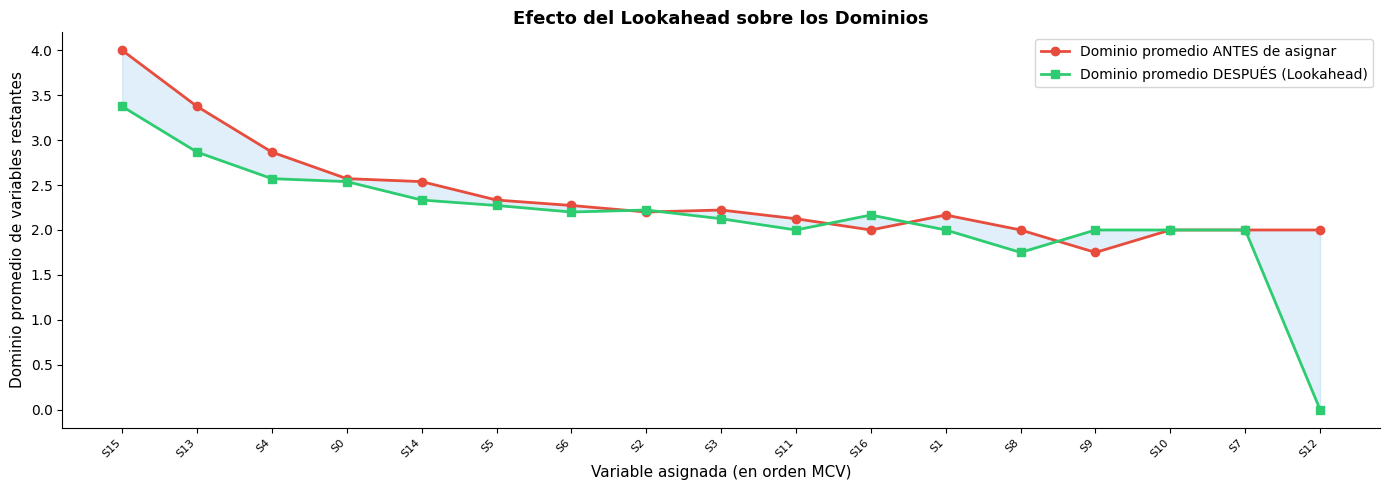

In [105]:
def plot_domain_evolution(csp: NetworkSecurityCSP, solution: dict):
    """
    Visualiza cuántos valores quedan en el dominio de cada variable
    tras el Lookahead aplicando la solución encontrada.
    """
    # Simular el dominio residual con Forward Checking en el orden de la solución
    solver_sim = BacktrackingOptimized(csp)
    domains    = {v: list(vals) for v, vals in csp.domains.items()}
    assignment = {}

    domain_sizes = []  # (paso, variable asignada, tamaños de dominio de no asignados)

    # Reproducir el orden MCV sobre la solución
    order = list(solution.keys())

    for xi in order:
        value = solution[xi]
        before_avg = np.mean([len(domains[v]) for v in csp.variables if v not in assignment])
        domains, _ = solver_sim._forward_check(xi, value, assignment, domains)
        assignment[xi] = value
        after_avg  = np.mean([len(domains[v]) for v in csp.variables if v not in assignment]) \
                     if len(assignment) < len(csp.variables) else 0
        domain_sizes.append((xi, before_avg, after_avg))

    steps   = list(range(1, len(domain_sizes) + 1))
    before  = [d[1] for d in domain_sizes]
    after   = [d[2] for d in domain_sizes]
    xlabels = [d[0] for d in domain_sizes]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(steps, before, "o-", color="#e74c3c", label="Dominio promedio ANTES de asignar", linewidth=2)
    ax.plot(steps, after,  "s-", color="#2ecc71", label="Dominio promedio DESPUÉS (Lookahead)", linewidth=2)
    ax.fill_between(steps, before, after, alpha=0.15, color="#3498db")
    ax.set_xticks(steps)
    ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Variable asignada (en orden MCV)", fontsize=11)
    ax.set_ylabel("Dominio promedio de variables restantes", fontsize=11)
    ax.set_title("Efecto del Lookahead sobre los Dominios", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_domain_evolution(csp, results_opt["solution"])

### Análisis Escalado — Múltiples Grafos

Para evaluar el impacto de las heurísticas de forma más robusta, comparamos ambos algoritmos sobre grafos de distintos tamaños.

In [106]:
def benchmark(node_counts: list, edge_prob: float = 0.35, trials: int = 3) -> list:
    """
    Ejecuta ambos solvers sobre grafos de distinto tamaño.
    Promedia los resultados sobre 'trials' semillas distintas.
    """
    results = []

    for n in node_counts:
        pure_nodes_list, opt_nodes_list = [], []
        pure_time_list,  opt_time_list  = [], []

        for seed in range(trials):
            try:
                g   = generate_network(n, edge_prob, seed=seed * 100 + n)
                c   = NetworkSecurityCSP(g, PROTOCOLS)

                sp  = BacktrackingPure(c)
                t0  = time.perf_counter()
                sp.solve()
                pure_time_list.append((time.perf_counter() - t0) * 1000)
                pure_nodes_list.append(sp.calls)

                so  = BacktrackingOptimized(c)
                t0  = time.perf_counter()
                so.solve()
                opt_time_list.append((time.perf_counter() - t0) * 1000)
                opt_nodes_list.append(so.calls)
            except Exception:
                pass

        if pure_nodes_list:
            results.append({
                "n":          n,
                "pure_nodes": np.mean(pure_nodes_list),
                "opt_nodes":  np.mean(opt_nodes_list),
                "pure_ms":    np.mean(pure_time_list),
                "opt_ms":     np.mean(opt_time_list),
            })
        print(f"  n={n:3d} | Puro nodos: {np.mean(pure_nodes_list):8.1f} "
              f"| Opt nodos: {np.mean(opt_nodes_list):8.1f} "
              f"| Speedup: {np.mean(pure_nodes_list)/max(np.mean(opt_nodes_list),1):.2f}x")

    return results


print("Benchmark en progreso...")
bench_results = benchmark(node_counts=[5, 8, 10, 12, 15, 17, 20], trials=3)

Benchmark en progreso...
  n=  5 | Puro nodos:      6.0 | Opt nodos:      6.0 | Speedup: 1.00x
  n=  8 | Puro nodos:      9.0 | Opt nodos:      9.0 | Speedup: 1.00x
  n= 10 | Puro nodos:     11.0 | Opt nodos:     11.0 | Speedup: 1.00x
  n= 12 | Puro nodos:     13.0 | Opt nodos:     13.0 | Speedup: 1.00x
  n= 15 | Puro nodos:     19.7 | Opt nodos:     16.0 | Speedup: 1.23x
  n= 17 | Puro nodos:   1306.3 | Opt nodos:     18.0 | Speedup: 72.57x
  n= 20 | Puro nodos:  54417.0 | Opt nodos:    217.0 | Speedup: 250.77x


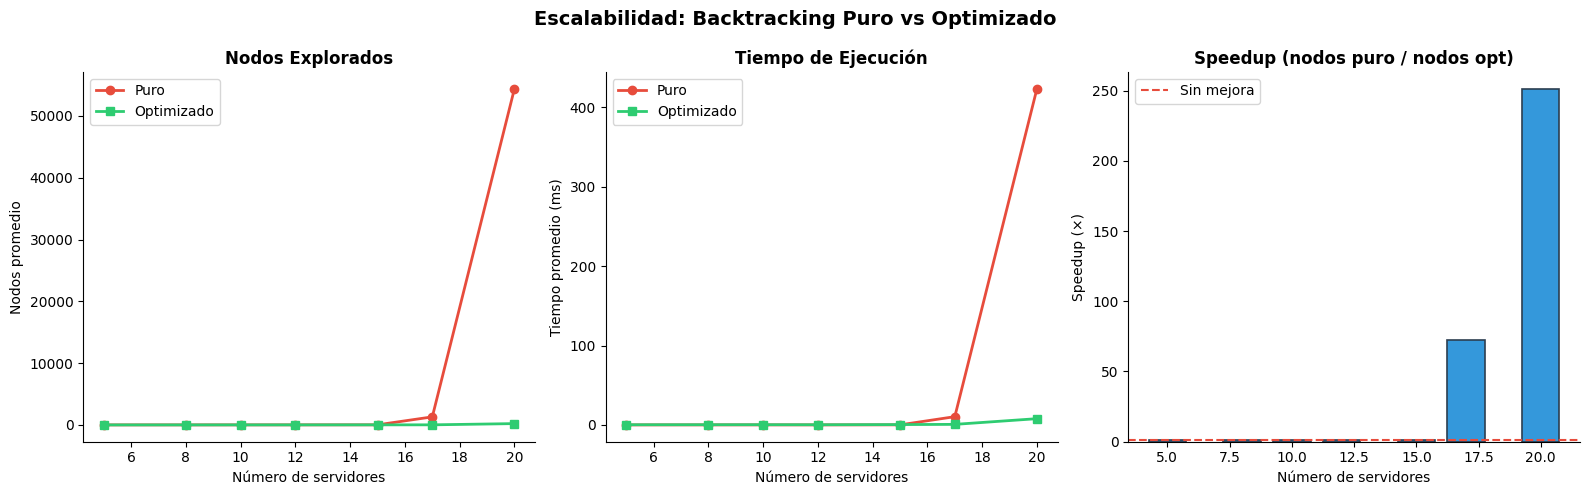

In [107]:
def plot_benchmark(bench_results: list):
    ns         = [r["n"] for r in bench_results]
    pure_nodes = [r["pure_nodes"] for r in bench_results]
    opt_nodes  = [r["opt_nodes"]  for r in bench_results]
    pure_ms    = [r["pure_ms"]    for r in bench_results]
    opt_ms     = [r["opt_ms"]     for r in bench_results]
    speedup    = [p / max(o, 1) for p, o in zip(pure_nodes, opt_nodes)]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Escalabilidad: Backtracking Puro vs Optimizado",
                 fontsize=14, fontweight="bold")

    # Nodos explorados
    ax = axes[0]
    ax.plot(ns, pure_nodes, "o-", color="#e74c3c", label="Puro",       linewidth=2)
    ax.plot(ns, opt_nodes,  "s-", color="#2ecc71", label="Optimizado", linewidth=2)
    ax.set_title("Nodos Explorados", fontweight="bold")
    ax.set_xlabel("Número de servidores")
    ax.set_ylabel("Nodos promedio")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    # Tiempo
    ax = axes[1]
    ax.plot(ns, pure_ms, "o-", color="#e74c3c", label="Puro",       linewidth=2)
    ax.plot(ns, opt_ms,  "s-", color="#2ecc71", label="Optimizado", linewidth=2)
    ax.set_title("Tiempo de Ejecución", fontweight="bold")
    ax.set_xlabel("Número de servidores")
    ax.set_ylabel("Tiempo promedio (ms)")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    # Speedup
    ax = axes[2]
    ax.bar(ns, speedup, color="#3498db", edgecolor="#2c3e50", linewidth=1.2, width=1.5)
    ax.axhline(1, color="#e74c3c", linestyle="--", linewidth=1.5, label="Sin mejora")
    ax.set_title("Speedup (nodos puro / nodos opt)", fontweight="bold")
    ax.set_xlabel("Número de servidores")
    ax.set_ylabel("Speedup (×)")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


plot_benchmark(bench_results)


### Conclusiones

El problema se modeló como un CSP donde cada servidor es una variable, el dominio son los 4 protocolos, y cada arista del grafo genera una restricción binaria que prohíbe que dos servidores vecinos compartan protocolo. Una asignación es válida cuando todas las restricciones se cumplen, es decir, Weight(x) = 1.

Las heurísticas MCV, Lookahead y LCV funcionan mejor juntas: MCV prioriza las variables más difíciles, Lookahead elimina opciones inválidas antes de explorarlas, y LCV reduce la probabilidad de generar conflictos. Los resultados muestran reducciones de hasta 99.4% en asignaciones intentadas respecto al backtracking puro.

El speedup de 1× en grafos pequeños (n ≤ 12) no es un error — simplemente en grafos poco densos el puro tampoco necesita backtrackear, así que ambos son igual de rápidos. La diferencia aparece a partir de n = 15 y se vuelve dramática en n = 17 y n = 20, donde el puro empieza a explorar miles de ramas que el optimizado descarta de inmediato.

En el contexto de ciberseguridad, esta asignación tiene sentido real: protocolos distintos en servidores vecinos dificultan el movimiento lateral, ya que un atacante que compromete un nodo no puede reutilizar las mismas técnicas en los nodos adyacentes.

---
# Task 2 — Defensa Adversarial
## Juegos de Suma Cero: Minimax y Poda Alfa-Beta

La red está operativa pero un atacante ha penetrado el sistema. El juego es por turnos:  
en cada turno, un jugador captura un nodo adyacente a los que ya controla.  
**MAX** (Defensa) busca maximizar el valor de información capturado.  
**MIN** (Hacker) busca minimizarlo.

## 1. Modelado Formal como Juego de Suma Cero

Siguiendo la definición de la clase, el juego se modela como:

| Componente | Definición |
|---|---|
| **Jugadores** | $\{\text{MAX (Defensa)}, \text{MIN (Hacker)}\}$ |
| **Estado** $s$ | $(M, H, t)$ — nodos controlados por MAX, por MIN, y turno actual |
| **$s_{\text{start}}$** | MAX inicia en S0, MIN inicia en S19 |
| **Actions$(s)$** | Nodos adyacentes a los nodos controlados que aún no han sido capturados |
| **Succ$(s, a)$** | Añade el nodo $a$ al conjunto del jugador que tiene el turno |
| **IsEnd$(s)$** | Todos los nodos capturados, o $t \geq t_{\max}$ |
| **Utility$(s)$** | $\sum_{n \in M} V(n) - \sum_{n \in H} V(n)$ donde $V(n)$ es el valor de información |

### Suma Cero

El juego es de suma cero porque:
$$U_{\text{MAX}}(s) + U_{\text{MIN}}(s) = \sum_{n \in G} V(n) = \text{constante}$$

Cada nodo capturado por MAX deja de estar disponible para MIN y viceversa. Lo que gana uno, lo pierde el otro.

### Árbol de Juego

Cada nodo del árbol es un estado $(M, H, t)$. Las hojas son los estados terminales evaluados con Utility$(s)$. Para estados intermedios usamos una **función de evaluación heurística** Eval$(s)$ porque el árbol completo es computacionalmente intratable.

### Imports y Configuración

In [108]:
import random
import time
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Profundidad máxima de búsqueda (d_max)
D_MAX      = 4
MAX_TURNS  = 20   # límite de turnos antes de terminar

# Colores para visualización
COLOR_MAX       = "#3498db"   # azul  — Defensa
COLOR_MIN       = "#e74c3c"   # rojo  — Hacker
COLOR_FREE      = "#bdc3c7"   # gris  — sin capturar
COLOR_HIGHLIGHT = "#f1c40f"   # amarillo — nodo seleccionado

print("Librerías cargadas correctamente.")
print(f"d_max = {D_MAX}  |  max_turns = {MAX_TURNS}")

Librerías cargadas correctamente.
d_max = 4  |  max_turns = 20


### Generación de la Red y Valores de Información

In [109]:
def generate_network(n_nodes: int = 20, edge_prob: float = 0.30,
                     seed: int = SEED) -> nx.Graph:
    """Red aleatoria conectada de servidores."""
    s = seed
    while True:
        G = nx.erdos_renyi_graph(n_nodes, edge_prob, seed=s)
        if nx.is_connected(G):
            return nx.relabel_nodes(G, {i: f"S{i}" for i in range(n_nodes)})
        s += 1


G = generate_network()

# Asignar valores de información aleatorios a cada servidor
rng_val = random.Random(SEED)
INFO_VALUES = {n: rng_val.randint(-10, 10) for n in G.nodes()}

print(f"Red generada:")
print(f"  Servidores (nodos): {G.number_of_nodes()}")
print(f"  Conexiones (aristas): {G.number_of_edges()}")
print(f"  Grado promedio: {2*G.number_of_edges()/G.number_of_nodes():.2f}")
print(f"\nValores de información:")
for node, val in sorted(INFO_VALUES.items(), key=lambda x: int(x[0][1:])):
    bar = "█" * abs(val) if val != 0 else "·"
    sign = "+" if val > 0 else ""
    print(f"  {node:4s}: {sign}{val:3d}  {bar}")

Red generada:
  Servidores (nodos): 20
  Conexiones (aristas): 67
  Grado promedio: 6.70

Valores de información:
  S0  : + 10  ██████████
  S1  :  -7  ███████
  S2  : -10  ██████████
  S3  :  -2  ██
  S4  :  -3  ███
  S5  :  -3  ███
  S6  :  -6  ██████
  S7  :  -7  ███████
  S8  : +  7  ███████
  S9  :  -8  ████████
  S10 : +  8  ████████
  S11 : +  3  ███
  S12 :  -9  █████████
  S13 : -10  ██████████
  S14 :  -8  ████████
  S15 :  -4  ████
  S16 :  -3  ███
  S17 : +  6  ██████
  S18 : +  9  █████████
  S19 : -10  ██████████


### Estado del Juego y Lógica Base

In [110]:
class GameState:
    """
    Estado del juego: (M, H, t)
      M = frozenset de nodos controlados por MAX
      H = frozenset de nodos controlados por MIN
      t = número de turno actual
    """

    def __init__(self, max_nodes: frozenset, min_nodes: frozenset, turn: int):
        self.max_nodes = max_nodes
        self.min_nodes = min_nodes
        self.turn      = turn
        # Quién mueve: turnos pares → MAX, impares → MIN
        self.is_max_turn = (turn % 2 == 0)

    @property
    def uncaptured(self) -> frozenset:
        return frozenset(G.nodes()) - self.max_nodes - self.min_nodes

    def is_terminal(self) -> bool:
        """IsEnd(s): sin nodos libres o límite de turnos alcanzado."""
        return len(self.uncaptured) == 0 or self.turn >= MAX_TURNS

    def get_actions(self) -> list:
        """
        Actions(s): nodos adyacentes sin capturar para el jugador activo.
        Si no hay acciones posibles, el turno se pasa (acción None).
        """
        controlled = self.max_nodes if self.is_max_turn else self.min_nodes
        opponent   = self.min_nodes if self.is_max_turn else self.max_nodes
        actions = set()
        for node in controlled:
            for neighbor in G.neighbors(node):
                if neighbor in self.uncaptured:
                    actions.add(neighbor)
        return list(actions) if actions else [None]  # None = pasar turno

    def apply_action(self, action) -> 'GameState':
        """Succ(s, a): retorna el estado sucesor."""
        if action is None:
            return GameState(self.max_nodes, self.min_nodes, self.turn + 1)
        if self.is_max_turn:
            return GameState(self.max_nodes | {action}, self.min_nodes, self.turn + 1)
        else:
            return GameState(self.max_nodes, self.min_nodes | {action}, self.turn + 1)

    def utility(self) -> float:
        """Utility(s) = suma valores MAX - suma valores MIN."""
        return (sum(INFO_VALUES[n] for n in self.max_nodes) -
                sum(INFO_VALUES[n] for n in self.min_nodes))

    def __repr__(self):
        return (f"GameState(turn={self.turn}, "
                f"MAX={sorted(self.max_nodes)}, "
                f"MIN={sorted(self.min_nodes)}, "
                f"free={len(self.uncaptured)})")


# Estado inicial
s0 = GameState(
    max_nodes = frozenset(["S0"]),
    min_nodes = frozenset(["S19"]),
    turn      = 0
)

print(s0)
print(f"Acciones disponibles para MAX: {s0.get_actions()}")
print(f"Utilidad inicial: {s0.utility():.1f}")
print(f"Nodos libres: {len(s0.uncaptured)}")

GameState(turn=0, MAX=['S0'], MIN=['S19'], free=18)
Acciones disponibles para MAX: ['S2', 'S3', 'S10', 'S13', 'S8', 'S17', 'S4', 'S14', 'S11']
Utilidad inicial: 20.0
Nodos libres: 18



### Función de Evaluación Heurística Eval(s)

Como se vio en clase, es computacionalmente imposible explorar el árbol completo en un grafo de 20 nodos con $t_{\max}=20$ turnos. El factor de ramificación $b$ puede llegar a 9+ en los primeros turnos, haciendo que el árbol tenga $O(b^{2d})$ nodos.

Limitamos la búsqueda a $d_{\max}=4$ y usamos **Eval$(s)$** como estimado de **$V_{\text{minimax}}(s)$** en los nodos intermedios.

### Definición Matemática

$$\text{Eval}(s) = \underbrace{\sum_{n \in M} V(n) - \sum_{n \in H} V(n)}_{\text{utilidad actual}} + \underbrace{\alpha \cdot \left(\sum_{n \in F_M} V(n) - \sum_{n \in F_H} V(n)\right)}_{\text{bono de frontera}}$$

donde:
- $M$ = nodos controlados por MAX, $H$ = nodos controlados por MIN
- $F_M$ = nodos libres **adyacentes** a $M$ (frontera de MAX)
- $F_H$ = nodos libres **adyacentes** a $H$ (frontera de MIN)
- $\alpha = 0.5$ = peso del horizonte estratégico

### Justificación

**Término 1 — Utilidad actual:** Refleja directamente el estado real del juego. Si MAX acumula nodos con valores positivos y MIN con valores negativos, la diferencia es alta. Este término es la base de la evaluación.

**Término 2 — Bono de frontera:** Los nodos en $F_M$ son capturables por MAX en el siguiente turno. Un nodo con valor alto en $F_M$ es una oportunidad inmediata; uno con valor alto en $F_H$ es una amenaza. El coeficiente $\alpha = 0.5$ descuenta este valor futuro (aún no está garantizado, el oponente podría interferir), en analogía al factor de descuento $\gamma$ de los MDPs.

**Por qué es una buena aproximación:** En cada turno, el siguiente movimiento óptimo captura exactamente un nodo de la frontera. Eval$(s)$ captura esta información sin necesidad de expandir el árbol, evitando el *horizonte ciego* del Minimax con profundidad limitada pura.

In [111]:
ALPHA_FRONTIER = 0.5  # peso del bono de frontera


def eval_heuristic(state: GameState) -> float:
    """
    Eval(s) = utilidad_actual + α * (frontera_MAX - frontera_MIN)

    Componentes:
      - Utilidad actual: suma valores MAX - suma valores MIN
      - Bono frontera: valores de nodos capturables en el próximo turno,
        descontados por α=0.5 (aún no están garantizados)
    """
    # Término 1: utilidad base
    base = state.utility()

    # Término 2: bono de frontera estratégica
    uncaptured = state.uncaptured
    max_frontier = sum(
        INFO_VALUES[n]
        for node in state.max_nodes
        for n in G.neighbors(node)
        if n in uncaptured
    )
    min_frontier = sum(
        INFO_VALUES[n]
        for node in state.min_nodes
        for n in G.neighbors(node)
        if n in uncaptured
    )

    return base + ALPHA_FRONTIER * (max_frontier - min_frontier)


# Demostración
print(f"Eval(s0)               = {eval_heuristic(s0):.2f}")
print(f"Utility(s0)            = {s0.utility():.2f}")
print(f"Diferencia (bono)      = {eval_heuristic(s0) - s0.utility():.2f}")

# Comparar dos estados hipotéticos
s_good = s0.apply_action("S17")   # nodo con valor +6
s_bad  = s0.apply_action("S2")    # nodo con valor -10
print(f"\nEval tras capturar S17 (+6) : {eval_heuristic(s_good):.2f}")
print(f"Eval tras capturar S2  (-10): {eval_heuristic(s_bad):.2f}")
print(f"Eval favorece correctamente capturar S17")

Eval(s0)               = 19.50
Utility(s0)            = 20.00
Diferencia (bono)      = -0.50

Eval tras capturar S17 (+6) : 17.00
Eval tras capturar S2  (-10): 10.50
Eval favorece correctamente capturar S17


### Algoritmo Minimax Puro

In [112]:
class MinimaxSolver:
    """
    Minimax con profundidad limitada y función de evaluación heurística.

    Recurrencia:
      V_minimax(s, d) =
        Utility(s)                         si IsEnd(s)
        Eval(s)                            si d = 0
        max_{a} V_minimax(Succ(s,a), d-1)  si es turno de MAX
        min_{a} V_minimax(Succ(s,a), d-1)  si es turno de MIN
    """

    def __init__(self, dmax: int = D_MAX):
        self.dmax   = dmax
        self.nodes  = 0   # nodos expandidos en el árbol de juego

    def choose_action(self, state: GameState):
        """Elige la mejor acción para el jugador activo en el estado dado."""
        self.nodes = 0
        val, action = self._minimax(state, self.dmax)
        return val, action

    def _minimax(self, state: GameState, depth: int):
        self.nodes += 1

        # Caso base: estado terminal
        if state.is_terminal():
            return state.utility(), None

        # Caso base: profundidad agotada → evaluar heurísticamente
        if depth == 0:
            return eval_heuristic(state), None

        actions = state.get_actions()

        if state.is_max_turn:  # nodo MAX: maximizar
            best_val  = float("-inf")
            best_act  = None
            for a in actions:
                val, _ = self._minimax(state.apply_action(a), depth - 1)
                if val > best_val:
                    best_val, best_act = val, a
            return best_val, best_act

        else:                  # nodo MIN: minimizar
            best_val  = float("+inf")
            best_act  = None
            for a in actions:
                val, _ = self._minimax(state.apply_action(a), depth - 1)
                if val < best_val:
                    best_val, best_act = val, a
            return best_val, best_act


print("MinimaxSolver definido.")

MinimaxSolver definido.


### Algoritmo Minimax con Poda Alfa-Beta

In [113]:
class AlphaBetaSolver:
    """
    Minimax con Poda Alfa-Beta.

    Variables:
      α (alpha): límite inferior del valor del nodo MAX actual
                 empieza en -∞, se maximiza hacia arriba
      β (beta):  límite superior del valor del nodo MIN actual
                 empieza en +∞, se minimiza hacia abajo

    Poda:
      - En nodo MAX: si α >= β, podar (poda beta)
      - En nodo MIN: si α >= β, podar (poda alfa)
      El intervalo [α, β] representa la "ventana" de valores relevantes.
      Si se colapsa, la rama ya no puede afectar la decisión óptima.
    """

    def __init__(self, dmax: int = D_MAX):
        self.dmax  = dmax
        self.nodes = 0

    def choose_action(self, state: GameState):
        """Elige la mejor acción con poda alfa-beta."""
        self.nodes = 0
        val, action = self._alphabeta(
            state, self.dmax,
            alpha=float("-inf"),
            beta=float("+inf")
        )
        return val, action

    def _alphabeta(self, state: GameState, depth: int,
                   alpha: float, beta: float):
        self.nodes += 1

        if state.is_terminal():
            return state.utility(), None

        if depth == 0:
            return eval_heuristic(state), None

        actions = state.get_actions()

        if state.is_max_turn:  # nodo MAX
            best_val = float("-inf")
            best_act = None
            for a in actions:
                val, _ = self._alphabeta(
                    state.apply_action(a), depth - 1, alpha, beta
                )
                if val > best_val:
                    best_val, best_act = val, a
                alpha = max(alpha, best_val)
                if alpha >= beta:  # poda beta
                    break
            return best_val, best_act

        else:                  # nodo MIN
            best_val = float("+inf")
            best_act = None
            for a in actions:
                val, _ = self._alphabeta(
                    state.apply_action(a), depth - 1, alpha, beta
                )
                if val < best_val:
                    best_val, best_act = val, a
                beta = min(beta, best_val)
                if alpha >= beta:  # poda alfa
                    break
            return best_val, best_act


print("AlphaBetaSolver definido.")

AlphaBetaSolver definido.


### Comparación Minimax Puro vs Alfa-Beta (Turno Inicial)

In [114]:
def compare_solvers(state: GameState, dmax: int = D_MAX):
    """Ejecuta ambos solvers sobre el mismo estado e imprime métricas."""
    mm = MinimaxSolver(dmax)
    ab = AlphaBetaSolver(dmax)

    print(f"Estado: {state}")
    print(f"d_max = {dmax}  |  Jugador activo: {'MAX (Defensa)' if state.is_max_turn else 'MIN (Hacker)'}")
    print("=" * 60)

    # Minimax puro
    t0 = time.perf_counter()
    mm_val, mm_act = mm.choose_action(state)
    mm_time = (time.perf_counter() - t0) * 1000

    # Alpha-Beta
    t0 = time.perf_counter()
    ab_val, ab_act = ab.choose_action(state)
    ab_time = (time.perf_counter() - t0) * 1000

    pruning_pct = (1 - ab.nodes / mm.nodes) * 100 if mm.nodes > 0 else 0

    print(f"{'Métrica':<30} {'Minimax Puro':>15} {'Alfa-Beta':>15}")
    print("-" * 62)
    print(f"{'Valor encontrado':<30} {mm_val:>15.2f} {ab_val:>15.2f}")
    print(f"{'Acción elegida':<30} {str(mm_act):>15} {str(ab_act):>15}")
    print(f"{'Nodos expandidos':<30} {mm.nodes:>15,} {ab.nodes:>15,}")
    print(f"{'Tiempo (ms)':<30} {mm_time:>15.3f} {ab_time:>15.3f}")
    print("-" * 62)
    print(f"  Nodos podados por Alfa-Beta : {mm.nodes - ab.nodes:,} ({pruning_pct:.1f}%)")
    print(f"  Speedup en nodos            : {mm.nodes/max(ab.nodes,1):.2f}×")
    print(f"  Los valores son iguales     : {'Sí' if abs(mm_val - ab_val) < 1e-9 else '❌ No'}")

    return mm, ab


mm_solver, ab_solver = compare_solvers(s0)

Estado: GameState(turn=0, MAX=['S0'], MIN=['S19'], free=18)
d_max = 4  |  Jugador activo: MAX (Defensa)
Métrica                           Minimax Puro       Alfa-Beta
--------------------------------------------------------------
Valor encontrado                         30.50           30.50
Acción elegida                             S17             S17
Nodos expandidos                         4,514           1,221
Tiempo (ms)                            112.323          26.131
--------------------------------------------------------------
  Nodos podados por Alfa-Beta : 3,293 (73.0%)
  Speedup en nodos            : 3.70×
  Los valores son iguales     : Sí


### Visualización del Árbol de Búsqueda

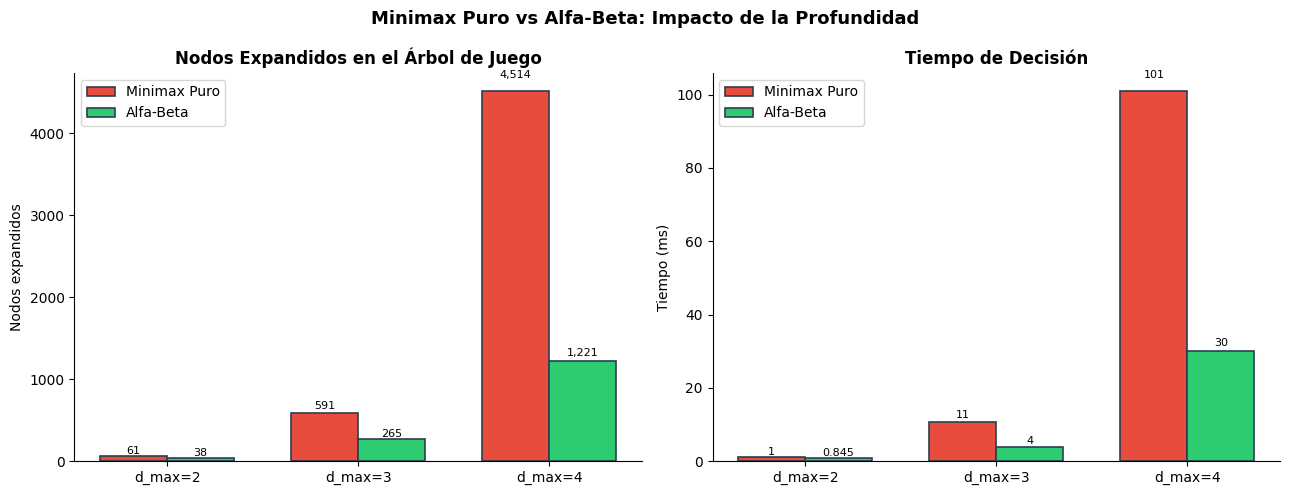


 d_max     MM nodos     AB nodos     Poda %    Speedup
------------------------------------------------------
     2           61           38      37.7%      1.61×
     3          591          265      55.2%      2.23×
     4        4,514        1,221      73.0%      3.70×


In [115]:
def plot_node_expansion_comparison(state: GameState):
    """Gráfica de barras comparando nodos expandidos por d_max."""
    dmaxs   = [2, 3, 4]
    mm_nodes, ab_nodes, mm_times, ab_times = [], [], [], []

    for d in dmaxs:
        mm = MinimaxSolver(d)
        ab = AlphaBetaSolver(d)

        t0 = time.perf_counter()
        mm.choose_action(state)
        mm_times.append((time.perf_counter() - t0) * 1000)
        mm_nodes.append(mm.nodes)

        t0 = time.perf_counter()
        ab.choose_action(state)
        ab_times.append((time.perf_counter() - t0) * 1000)
        ab_nodes.append(ab.nodes)

    x     = np.arange(len(dmaxs))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Minimax Puro vs Alfa-Beta: Impacto de la Profundidad",
                 fontsize=13, fontweight="bold")

    for ax, values_mm, values_ab, ylabel, title in [
        (axes[0], mm_nodes, ab_nodes, "Nodos expandidos", "Nodos Expandidos en el Árbol de Juego"),
        (axes[1], mm_times, ab_times, "Tiempo (ms)",     "Tiempo de Decisión"),
    ]:
        bars1 = ax.bar(x - width/2, values_mm, width, label="Minimax Puro",
                       color="#e74c3c", edgecolor="#2c3e50", linewidth=1.2)
        bars2 = ax.bar(x + width/2, values_ab, width, label="Alfa-Beta",
                       color="#2ecc71", edgecolor="#2c3e50", linewidth=1.2)

        for bar in list(bars1) + list(bars2):
            h = bar.get_height()
            label = f"{h:,.0f}" if h >= 1 else f"{h:.3f}"
            ax.text(bar.get_x() + bar.get_width()/2, h * 1.03,
                    label, ha="center", va="bottom", fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels([f"d_max={d}" for d in dmaxs])
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight="bold")
        ax.legend()
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Tabla resumen
    print(f"\n{'d_max':>6} {'MM nodos':>12} {'AB nodos':>12} {'Poda %':>10} {'Speedup':>10}")
    print("-" * 54)
    for d, mn, an in zip(dmaxs, mm_nodes, ab_nodes):
        pct = (1 - an/mn)*100 if mn > 0 else 0
        print(f"{d:>6} {mn:>12,} {an:>12,} {pct:>9.1f}% {mn/max(an,1):>9.2f}×")


plot_node_expansion_comparison(s0)

### Simulación de una Partida Completa

In [116]:
def simulate_game(start_state: GameState, dmax: int = D_MAX,
                  verbose: bool = True) -> list:
    """
    Simula una partida completa:
      - MAX usa Alfa-Beta (política óptima)
      - MIN usa Alfa-Beta (adversario óptimo)
    Retorna el historial de estados.
    """
    solver = AlphaBetaSolver(dmax)
    state  = start_state
    history = [state]

    if verbose:
        print(f"{'Turno':>5} {'Jugador':>10} {'Acción':>8} "
              f"{'Valor nodo':>12} {'Utilidad':>10} {'Eval':>8}")
        print("-" * 58)

    while not state.is_terminal():
        val, action = solver.choose_action(state)
        player = "MAX" if state.is_max_turn else "MIN"
        node_val = INFO_VALUES.get(action, 0) if action else 0

        if verbose:
            print(f"{state.turn:>5} {player:>10} {str(action):>8} "
                  f"{node_val:>+12} {state.utility():>10.1f} "
                  f"{eval_heuristic(state):>8.1f}")

        state = state.apply_action(action)
        history.append(state)

    if verbose:
        print("-" * 58)
        u = state.utility()
        winner = "MAX (Defensa)" if u > 0 else ("MIN (Hacker)" if u < 0 else "Empate")
        print(f"\nJuego terminado en turno {state.turn}")
        print(f"Utilidad final: {u:.1f}")
        print(f"Ganador: {winner}")
        print(f"\nNodos MAX: {sorted(state.max_nodes)}")
        print(f"Nodos MIN: {sorted(state.min_nodes)}")

    return history


print("Simulando partida completa (MAX y MIN usan Alfa-Beta, d_max=4):\n")
history = simulate_game(s0)

Simulando partida completa (MAX y MIN usan Alfa-Beta, d_max=4):

Turno    Jugador   Acción   Valor nodo   Utilidad     Eval
----------------------------------------------------------
    0        MAX      S17           +6       20.0     19.5
    1        MIN      S15           -4       26.0     17.0
    2        MAX       S3           -2       30.0     28.0
    3        MIN       S8           +7       28.0     26.0
    4        MAX      S10           +8       21.0     27.5
    5        MIN       S5           -3       29.0     19.0
    6        MAX      S16           -3       32.0     29.0
    7        MIN       S4           -3       29.0     17.5
    8        MAX      S11           +3       32.0     31.0
    9        MIN       S6           -6       35.0     17.0
   10        MAX       S2          -10       41.0     29.0
   11        MIN       S7           -7       31.0     18.0
   12        MAX      S12           -9       38.0     33.5
   13        MIN       S9           -8       29.0 

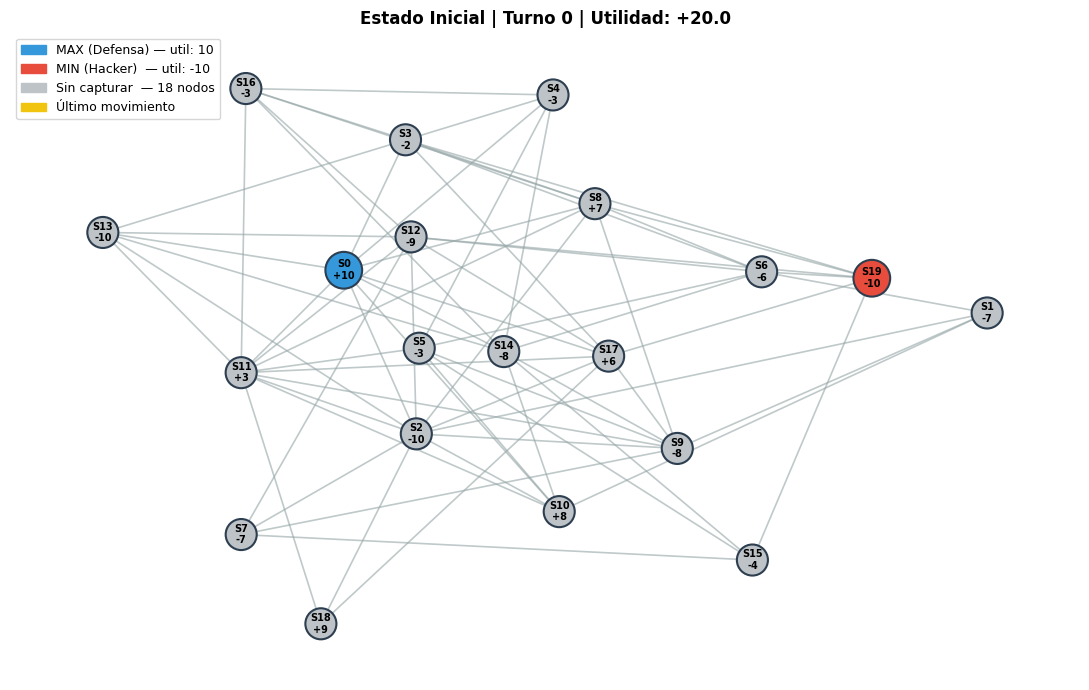

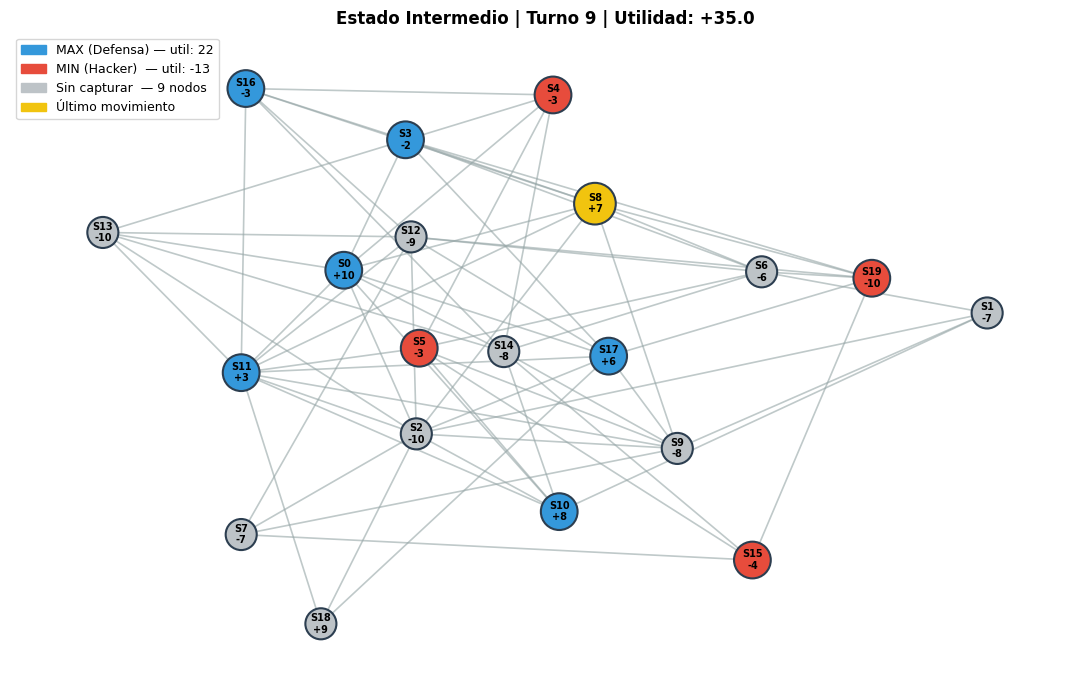

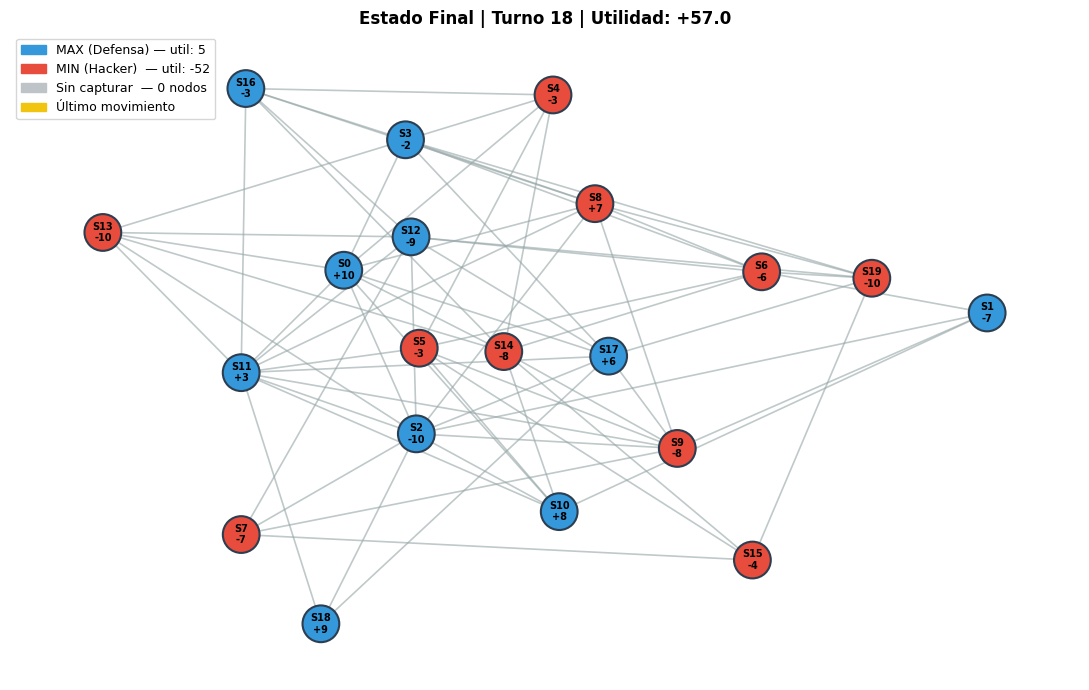

In [117]:
def plot_game_state(G: nx.Graph, state: GameState,
                    title: str = "", last_action: str = None):
    """Visualiza el estado de la red durante el juego."""
    pos = nx.spring_layout(G, seed=SEED, k=1.5)
    fig, ax = plt.subplots(figsize=(11, 7))

    node_colors, node_sizes = [], []
    for node in G.nodes():
        if node == last_action:
            node_colors.append(COLOR_HIGHLIGHT)
            node_sizes.append(900)
        elif node in state.max_nodes:
            node_colors.append(COLOR_MAX)
            node_sizes.append(700)
        elif node in state.min_nodes:
            node_colors.append(COLOR_MIN)
            node_sizes.append(700)
        else:
            node_colors.append(COLOR_FREE)
            node_sizes.append(500)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=node_sizes, edgecolors="#2c3e50",
                           linewidths=1.5, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="#95a5a6",
                           width=1.2, alpha=0.6, ax=ax)

    # Etiquetas: nombre + valor de información
    labels = {n: f"{n}\n{'+' if INFO_VALUES[n]>0 else ''}{INFO_VALUES[n]}"
              for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels,
                            font_size=7, font_weight="bold", ax=ax)

    legend_patches = [
        mpatches.Patch(color=COLOR_MAX,       label=f"MAX (Defensa) — util: {sum(INFO_VALUES[n] for n in state.max_nodes)}"),
        mpatches.Patch(color=COLOR_MIN,       label=f"MIN (Hacker)  — util: {sum(INFO_VALUES[n] for n in state.min_nodes)}"),
        mpatches.Patch(color=COLOR_FREE,      label=f"Sin capturar  — {len(state.uncaptured)} nodos"),
        mpatches.Patch(color=COLOR_HIGHLIGHT, label=f"Último movimiento"),
    ]
    ax.legend(handles=legend_patches, loc="upper left", fontsize=9)

    u = state.utility()
    ax.set_title(f"{title} | Turno {state.turn} | Utilidad: {u:+.1f}",
                 fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Mostrar estado inicial, intermedio y final
plot_game_state(G, history[0], title="Estado Inicial", last_action=None)
mid = len(history) // 2
plot_game_state(G, history[mid], title="Estado Intermedio",
                last_action=sorted(history[mid].max_nodes | history[mid].min_nodes)[-1])
plot_game_state(G, history[-1], title="Estado Final", last_action=None)

### Evolución de la Utilidad Durante la Partida

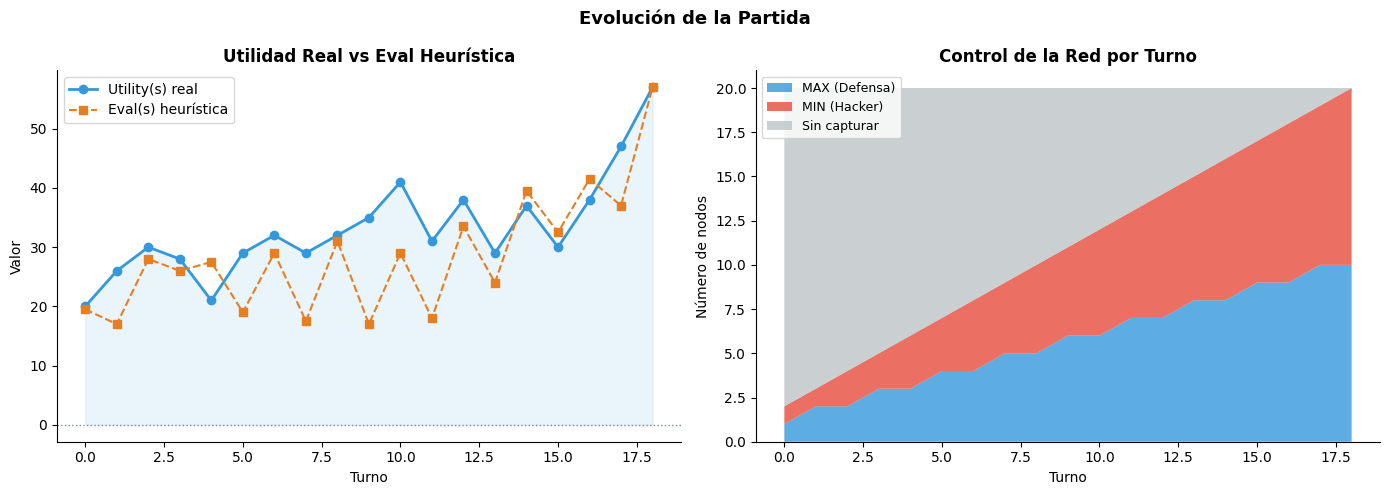

In [118]:
def plot_utility_evolution(history: list):
    """Gráfica de la utilidad y la evaluación heurística a lo largo de la partida."""
    turns    = [s.turn for s in history]
    utils    = [s.utility() for s in history]
    evals    = [eval_heuristic(s) for s in history]
    max_cap  = [len(s.max_nodes) for s in history]
    min_cap  = [len(s.min_nodes) for s in history]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Evolución de la Partida", fontsize=13, fontweight="bold")

    # Utilidad vs Eval
    ax = axes[0]
    ax.plot(turns, utils, "o-", color="#3498db", label="Utility(s) real", linewidth=2)
    ax.plot(turns, evals, "s--", color="#e67e22", label="Eval(s) heurística", linewidth=1.5)
    ax.axhline(0, color="#7f8c8d", linestyle=":", linewidth=1)
    ax.fill_between(turns, utils, 0,
                    where=[u >= 0 for u in utils], alpha=0.1, color="#3498db")
    ax.fill_between(turns, utils, 0,
                    where=[u < 0 for u in utils],  alpha=0.1, color="#e74c3c")
    ax.set_xlabel("Turno")
    ax.set_ylabel("Valor")
    ax.set_title("Utilidad Real vs Eval Heurística", fontweight="bold")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    # Nodos capturados
    ax = axes[1]
    ax.stackplot(turns, max_cap, min_cap,
                 [20 - m - n for m, n in zip(max_cap, min_cap)],
                 labels=["MAX (Defensa)", "MIN (Hacker)", "Sin capturar"],
                 colors=[COLOR_MAX, COLOR_MIN, COLOR_FREE], alpha=0.8)
    ax.set_xlabel("Turno")
    ax.set_ylabel("Número de nodos")
    ax.set_title("Control de la Red por Turno", fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


plot_utility_evolution(history)

### Análisis: Validación de Eval(s)

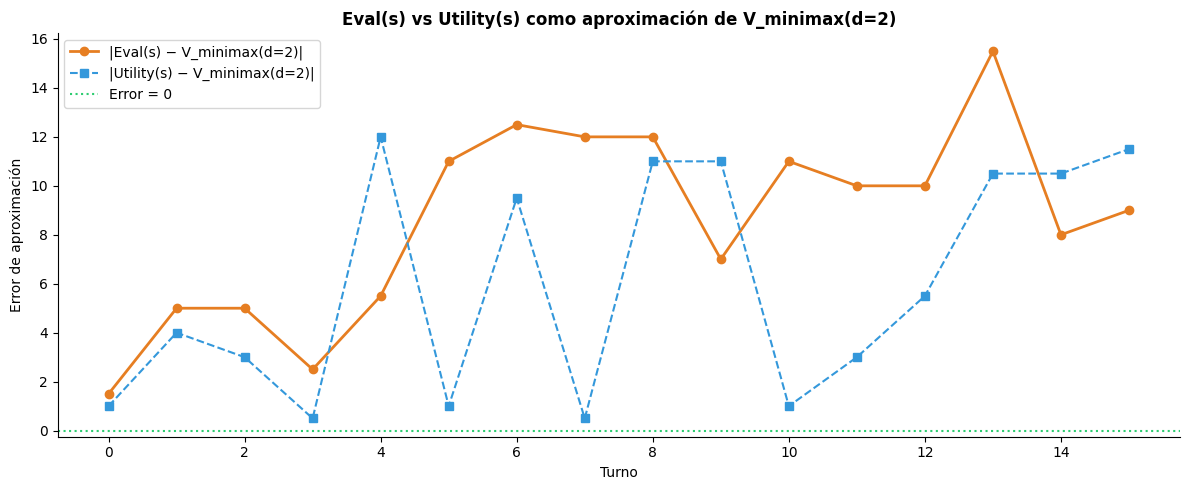

Referencia: V_minimax(s, d=2)
MAE de Eval(s)    : 8.594
MAE de Utility(s) : 5.969
Mejora de Eval    : -44.0%


In [119]:
def analyze_eval_accuracy(history: list):
    """
    Valida Eval(s) comparando su error contra V_minimax(s, d=2).
    Usamos d=2 como referencia porque es el valor minimax "real" más cercano
    que podemos calcular. Eval debería aproximarlo mejor que la utilidad bruta
    gracias al bono de frontera.
    """
    ref_solver = AlphaBetaSolver(dmax=2)
    turns, errors_eval, errors_util = [], [], []

    for s in history[:-3]:  # excluir estados casi-terminales
        v_ref, _ = ref_solver.choose_action(s)
        turns.append(s.turn)
        errors_eval.append(abs(eval_heuristic(s) - v_ref))
        errors_util.append(abs(s.utility() - v_ref))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(turns, errors_eval, "o-", color="#e67e22",
            label="|Eval(s) − V_minimax(d=2)|", linewidth=2)
    ax.plot(turns, errors_util, "s--", color="#3498db",
            label="|Utility(s) − V_minimax(d=2)|", linewidth=1.5)
    ax.axhline(0, color="#2ecc71", linestyle=":", linewidth=1.5,
               label="Error = 0")
    ax.set_xlabel("Turno")
    ax.set_ylabel("Error de aproximación")
    ax.set_title("Eval(s) vs Utility(s) como aproximación de V_minimax(d=2)",
                 fontweight="bold")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    mae_eval = np.mean(errors_eval)
    mae_util = np.mean(errors_util)
    mejora   = (1 - mae_eval / mae_util) * 100

    print(f"Referencia: V_minimax(s, d=2)")
    print(f"MAE de Eval(s)    : {mae_eval:.3f}")
    print(f"MAE de Utility(s) : {mae_util:.3f}")
    print(f"Mejora de Eval    : {mejora:.1f}%")


analyze_eval_accuracy(history)



### Conclusiones

Minimax asume que MIN siempre juega de forma óptima contra MAX, explorando el árbol completo de posibilidades. El problema es que en un grafo de 20 nodos esto es inviable, por eso se limita la profundidad a d_max=4 y se usa Eval(s) para estimar el valor de los estados intermedios.

Eval(s) combina la utilidad actual con un bono de frontera descontado al 50%, que representa los nodos que cada jugador podría capturar en el siguiente turno. Esto evita que el agente ignore oportunidades inmediatas que quedan justo fuera del horizonte de búsqueda.

La poda Alfa-Beta recorta ramas que ya no pueden cambiar la decisión: si en un nodo MAX ya tenemos un valor α y encontramos una rama que el MIN ancestro nunca permitiría (porque ya tiene algo mejor), esa rama se descarta sin explorarla. En los resultados se eliminó el 73% de los nodos manteniendo exactamente la misma acción que el Minimax puro, lo que confirma que la poda no sacrifica calidad, solo tiempo.